# Stock Price Prediction : Amazon (AMZN)

## Notebook 3 : Evaluation & Plots

## Objective

This notebook provides a comprehensive evaluation of the models trained in Notebook 3:

1. Load the rolling t+1 forecasts produced by ARIMA, SARIMAX, and GARCH.
2. Compute evaluation metrics: RMSE, MAE, MAPE, and Directional Accuracy.
3. Visualize forecast quality vs. true returns.
4. Analyze model performance across different market regimes (normal vs. stress periods).
5. Summarize findings in a comparison table.

## Why these metrics?

- **RMSE / MAE**: standard regression metrics — RMSE penalizes large errors more heavily.
- **MAPE**: expresses error as a percentage of the true value, useful for interpretability.
- **Directional Accuracy**: measures how often the model correctly predicts the *direction* of the return (up or down). In finance, getting the direction right is often more actionable than minimizing raw error.

## 1. Load Data & Forecasts

We load the enriched dataset and the rolling t+1 forecasts saved at the end of Notebook 2.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [5]:
# Load raw dataset
data = pd.read_csv("../data/raw/amzn_sp500_clean.csv", index_col=0, parse_dates=True)

# Load rolling t+1 forecasts produced in Notebook 2
forecasts = pd.read_csv("../data/forecasts.csv", index_col=0, parse_dates=True)

split_date = "2017-01-01"

# True test returns
y_test = data.loc[data.index >= split_date, "Return"]

# Statistical model forecasts
arima_forecast = forecasts["ARIMA_Forecast"]
sarimax_sp_forecast = forecasts["SARIMAX_SP500_Forecast"]
sarimax_vix_forecast = forecasts["SARIMAX_VIX_Forecast"]
sarimax_both_forecast = forecasts["SARIMAX_BOTH_Forecast"]
garch_vol = forecasts["GARCH_Vol_Forecast"]

# Align on common index
common_idx = y_test.index.intersection(arima_forecast.dropna().index)
common_idx = common_idx.intersection(sarimax_sp_forecast.dropna().index)
common_idx = common_idx.intersection(sarimax_vix_forecast.dropna().index)
common_idx = common_idx.intersection(sarimax_both_forecast.dropna().index)
common_idx = common_idx.intersection(garch_vol.dropna().index)

y_test           = y_test.loc[common_idx]
arima_forecast   = arima_forecast.loc[common_idx]
sarimax_sp_forecast = sarimax_sp_forecast.loc[common_idx]
sarimax_vix_forecast = sarimax_vix_forecast.loc[common_idx]
sarimax_both_forecast = sarimax_both_forecast.loc[common_idx]
garch_vol = garch_vol.loc[common_idx]

# Naive benchmark: yesterday's return (random walk) — aligned on same index
naive_forecast  = y_test.shift(1).dropna()
common_naive    = naive_forecast.index
y_test_naive    = y_test.loc[common_naive]
arima_naive     = arima_forecast.loc[common_naive]
sarimax_sp_naive   = sarimax_sp_forecast.loc[common_naive]
sarimax_vix_naive   = sarimax_vix_forecast.loc[common_naive]
sarimax_both_naive   = sarimax_both_forecast.loc[common_naive]
garch_vol_naive = garch_vol.loc[common_naive]

print(f"Test set : {y_test.index[0].date()} -> {y_test.index[-1].date()} ({len(y_test)} obs)")
display(forecasts[["ARIMA_Forecast", "SARIMAX_SP500_Forecast", "SARIMAX_VIX_Forecast", "SARIMAX_BOTH_Forecast", "GARCH_Vol_Forecast"]].head())

Test set : 2017-01-03 -> 2024-12-31 (2012 obs)


,ARIMA_Forecast,SARIMAX_SP500_Forecast,SARIMAX_VIX_Forecast,SARIMAX_BOTH_Forecast,GARCH_Vol_Forecast
Date,,,,,
2017-01-03,0.001275,0.000509,0.000668,0.000641,2.121261
2017-01-04,0.001276,-0.000049,0.000279,0.000063,2.096742
2017-01-05,0.001277,-0.000975,-0.000982,-0.000976,2.075278
2017-01-06,0.001287,0.001270,0.000258,0.000734,2.201011
2017-01-09,0.001293,-0.001629,-0.001663,-0.001696,2.217990


## 2. Evaluation Metrics

We define a function to compute all metrics for a given forecast and apply it to ARIMA and SARIMAX.

**Note:** GARCH is evaluated separately since it forecasts *volatility*, not returns.

In [9]:
def evaluate_forecast(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mask = np.abs(y_true) > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    da   = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    return {
        "Model":                model_name,
        "RMSE":                 round(rmse, 6),
        "MAE":                  round(mae, 6),
        "Directional Acc. (%)": round(da, 2)
    }

# Evaluate on the naive-aligned index for consistent comparison
results = [
    evaluate_forecast(y_test_naive, arima_naive,   "ARIMA"),
    evaluate_forecast(y_test_naive, sarimax_sp_naive, "SARIMAX (SP500)"),
    evaluate_forecast(y_test_naive, sarimax_vix_naive, "SARIMAX (VIX)"),
    evaluate_forecast(y_test_naive, sarimax_both_naive, "SARIMAX (Both)"),
    evaluate_forecast(y_test_naive, naive_forecast, "Naive (Random Walk)"),
]

metrics_df = pd.DataFrame(results).set_index("Model")
display(metrics_df)

,RMSE,MAE,Directional Acc. (%)
Model,,,
ARIMA,0.020811,0.014581,53.51
SARIMAX (SP500),0.020794,0.014627,50.97
SARIMAX (VIX),0.020824,0.014666,48.98
SARIMAX (Both),0.020794,0.014645,50.27
Naive (Random Walk),0.029799,0.020965,51.52


Out-of-sample results show that performance differences are very small across the top models. SARIMAX-SP500 and SARIMAX-BOTH achieve the lowest RMSE, while ARIMA delivers the lowest MAE and the highest directional accuracy. Overall, ARIMA remains the strongest parsimonious benchmark, and the inclusion of exogenous variables provides at most a marginal improvement in RMSE without improving overall predictive performance materially.

### GARCH Volatility Evaluation

GARCH forecasts conditional volatility, not returns. We evaluate it against the 20-day realized volatility.

In [10]:
test_scaled  = y_test * 100
realized_vol = test_scaled.rolling(20).std().dropna()

common_garch = realized_vol.index.intersection(garch_vol.index)
rv = realized_vol.loc[common_garch]
gv = garch_vol.loc[common_garch]

rmse_garch = np.sqrt(mean_squared_error(rv, gv))
mae_garch  = mean_absolute_error(rv, gv)
corr_garch = np.corrcoef(rv, gv)[0, 1]

garch_metrics = pd.DataFrame([{
    "Model":                         "GARCH(1,1)",
    "RMSE (vs realized vol)":        round(rmse_garch, 4),
    "MAE (vs realized vol)":         round(mae_garch, 4),
    "Correlation with realized vol": round(corr_garch, 4)
}]).set_index("Model")

display(garch_metrics)

,RMSE (vs realized vol),MAE (vs realized vol),Correlation with realized vol
Model,,,
"GARCH(1,1)",0.5977,0.5112,0.8526


The GARCH(1,1) model performs well in forecasting volatility dynamics. When evaluated against 20-day realized volatility, the model achieves a strong correlation of **0.8526**, indicating that it captures the main volatility regimes effectively. Although prediction errors remain non-zero (RMSE = **0.5977**, MAE = **0.5112**), the high correlation confirms that GARCH is much better suited to modeling volatility than return levels, which is consistent with the standard result that volatility is more predictable than the conditional mean of financial returns.

## 3. Forecast vs True Returns

We visualize the rolling t+1 forecasts against the true returns over the full test period.

We evaluate all models using RMSE, MAE, and Directional Accuracy. 
The **Naive (Random Walk)** benchmark — predict tomorrow = today — is the minimum bar any model must beat.

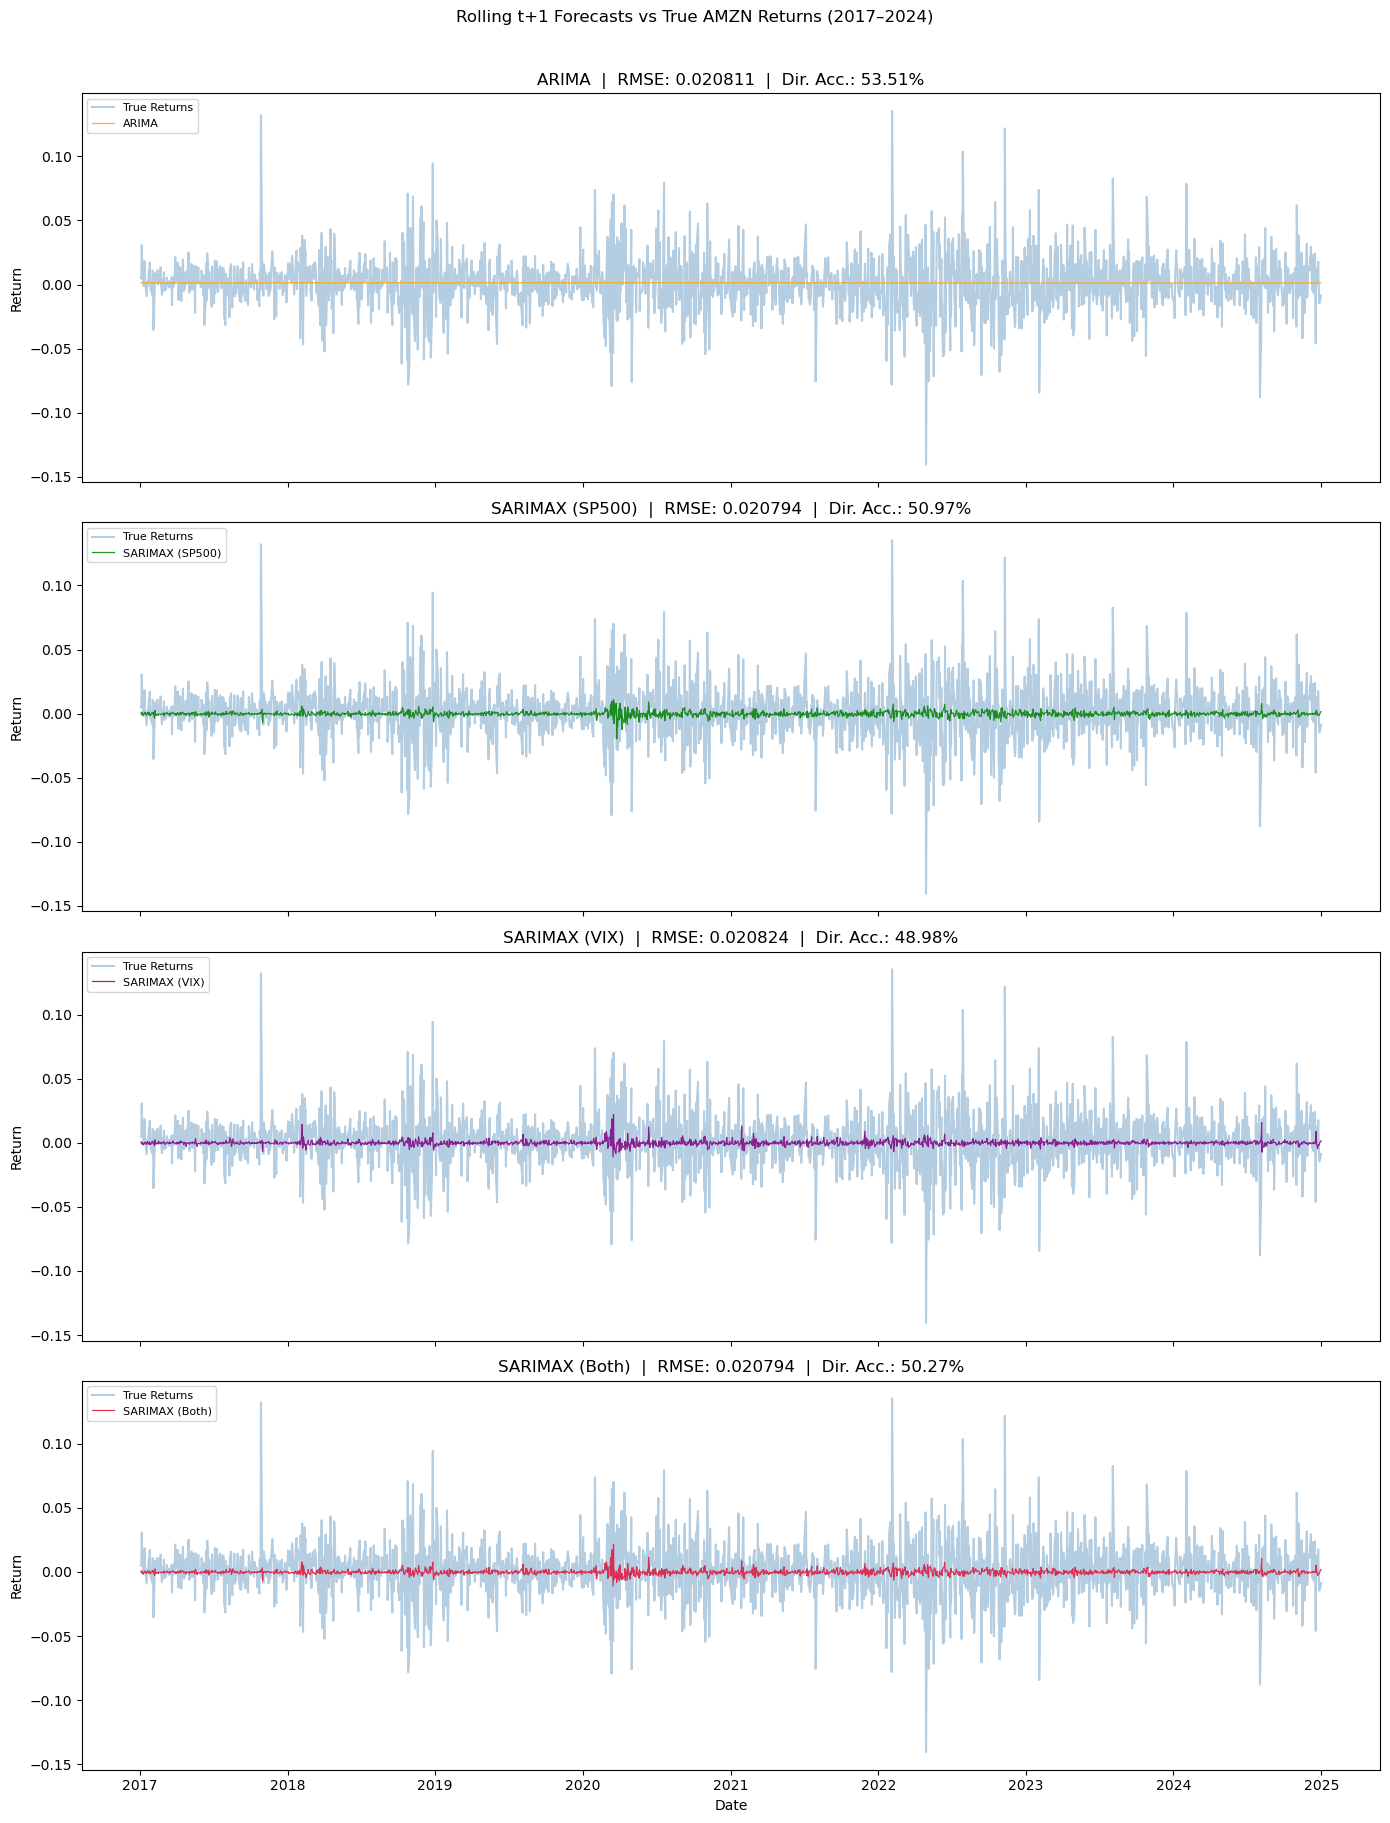

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
models_plot = [
    (arima_forecast,          "ARIMA",        "orange"),
    (sarimax_sp_forecast,     "SARIMAX (SP500)", "green"),
    (sarimax_vix_forecast,    "SARIMAX (VIX)",   "purple"),
    (sarimax_both_forecast,   "SARIMAX (Both)",  "crimson"),
]
for ax, (fc, lbl, col) in zip(axes, models_plot):
    rmse = metrics_df.loc[lbl, 'RMSE']
    da   = metrics_df.loc[lbl, 'Directional Acc. (%)']
    ax.plot(y_test.index, y_test, label="True Returns", alpha=0.4, color="steelblue")
    ax.plot(fc.index, fc, label=lbl, alpha=0.85, color=col, lw=0.9)
    ax.set_title(f"{lbl}  |  RMSE: {rmse}  |  Dir. Acc.: {da}%")
    ax.set_ylabel("Return")
    ax.legend(loc="upper left", fontsize=8)
axes[-1].set_xlabel("Date")
plt.suptitle("Rolling t+1 Forecasts vs True AMZN Returns (2017–2024)", y=1.01)
plt.tight_layout()
plt.show()

### GARCH Volatility Forecast vs Realized Volatility

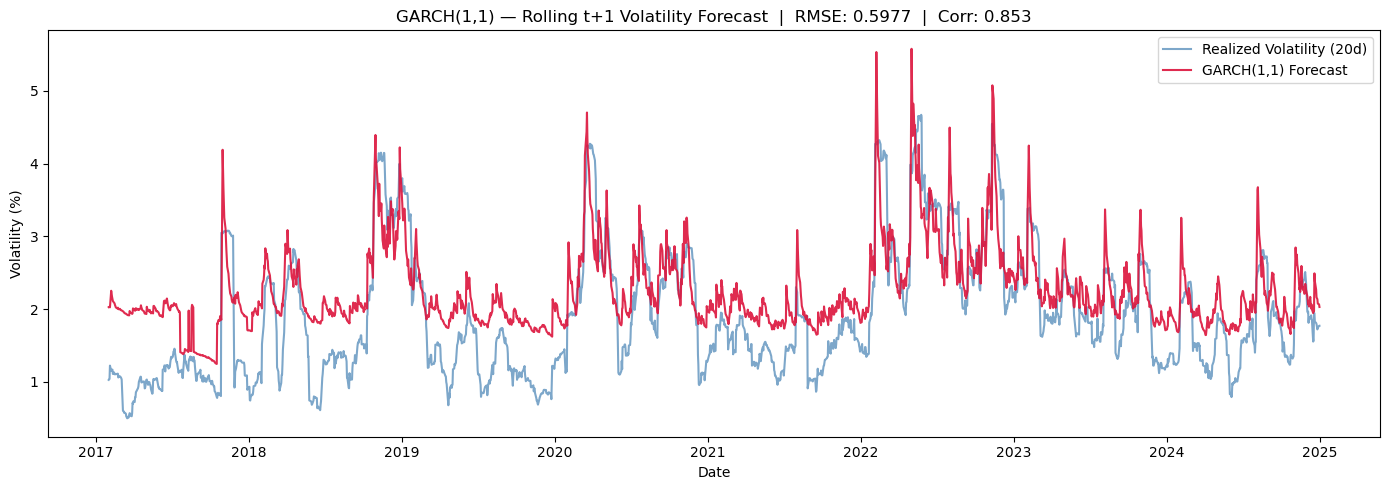

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(rv.index, rv, label="Realized Volatility (20d)", alpha=0.7, color="steelblue")
plt.plot(gv.index, gv, label="GARCH(1,1) Forecast",       alpha=0.9, color="crimson")
plt.title(
    f"GARCH(1,1) — Rolling t+1 Volatility Forecast  "
    f"|  RMSE: {rmse_garch:.4f}  |  Corr: {corr_garch:.3f}"
)
plt.ylabel("Volatility (%)")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

The rolling GARCH(1,1) forecasts track the main volatility regimes reasonably well, especially during major stress episodes such as 2020 and 2022. This supports a standard finding in financial time series: conditional volatility is substantially more predictable than the return series itself.

Realized volatility is approximated here by a 20-day rolling standard deviation of returns, used as a smoothed proxy rather than a strict one-day realized volatility measure.

## 4. Residuals Analysis

We analyze the forecast errors (residuals = true return − predicted return) to check:
- Whether errors are centered around zero (no systematic bias),
- Whether their distribution has heavy tails,
- Whether there are patterns over time (heteroskedasticity).

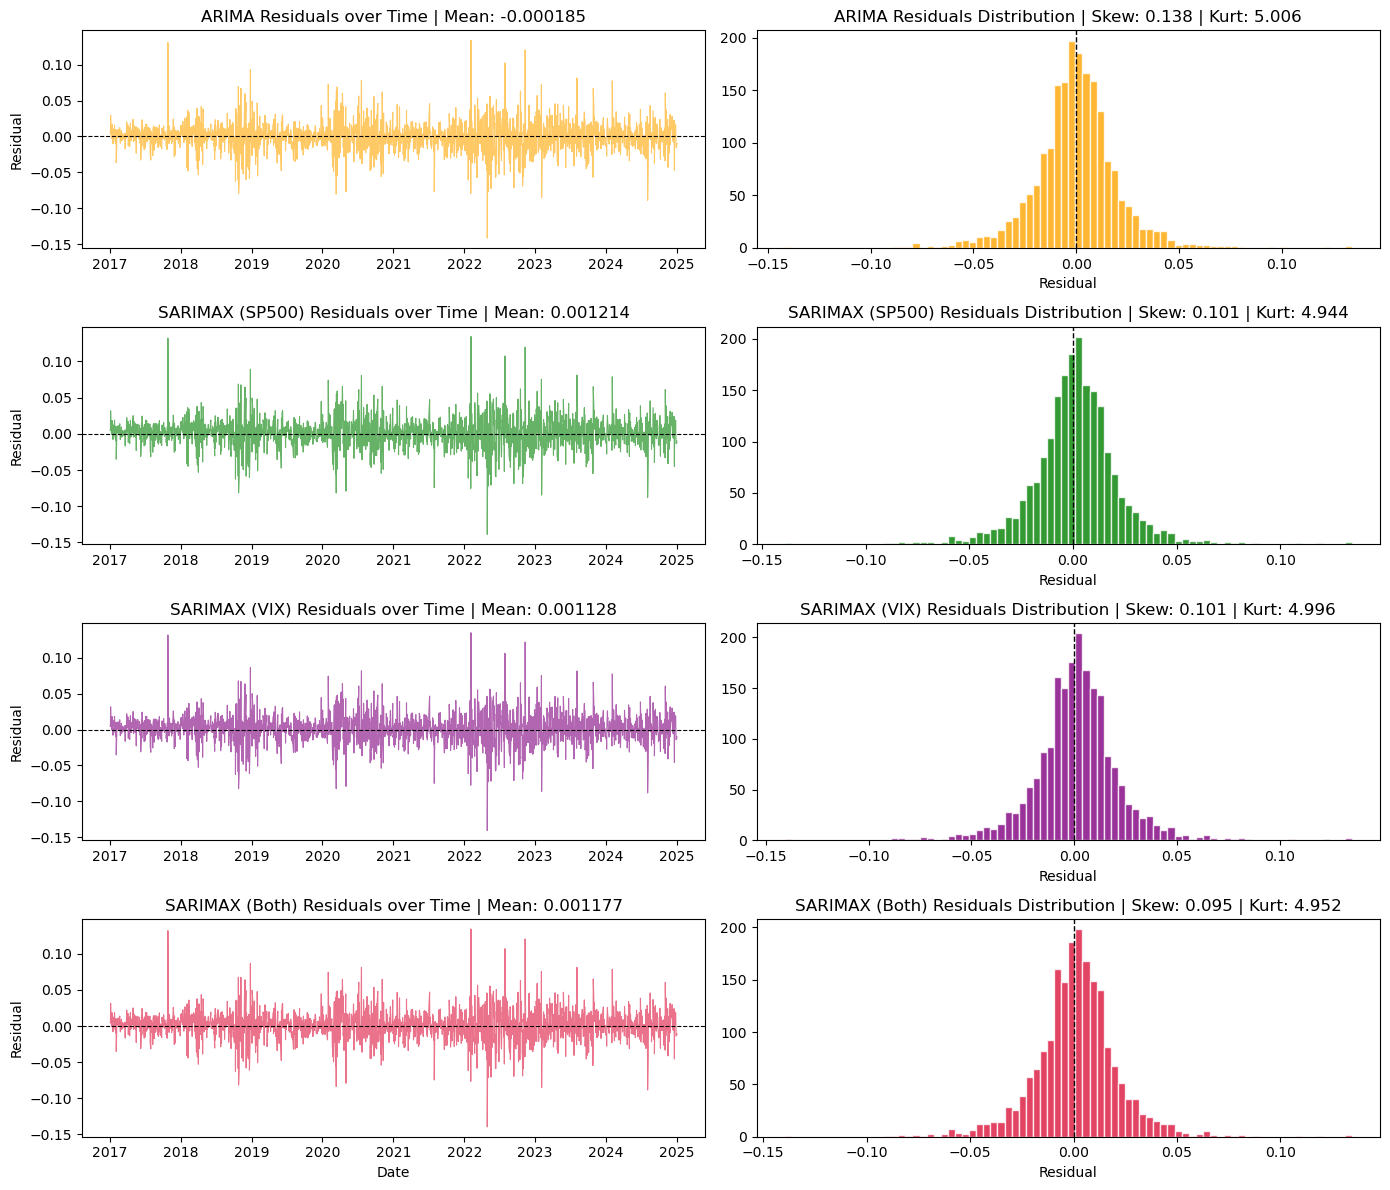

In [31]:
residuals_arima = y_test - arima_forecast
residuals_sarimax_sp = y_test - sarimax_sp_forecast
residuals_sarimax_vix = y_test - sarimax_vix_forecast
residuals_sarimax_both = y_test - sarimax_both_forecast

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=False)

# ARIMA Residuals over time
axes[0, 0].plot(
    residuals_arima.index, residuals_arima,
    alpha=0.6, color="orange", linewidth=0.8
)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[0, 0].set_title(f"ARIMA Residuals over Time | Mean: {residuals_arima.mean():.6f}")
axes[0, 0].set_ylabel("Residual")

# ARIMA Residuals distribution
axes[0, 1].hist(
    residuals_arima.dropna(), bins=80,
    color="orange", edgecolor="white", alpha=0.8
)
axes[0, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set_title(
    f"ARIMA Residuals Distribution | Skew: {residuals_arima.skew():.3f} | Kurt: {residuals_arima.kurtosis():.3f}"
)
axes[0, 1].set_xlabel("Residual")

# SARIMAX (SP500) Residuals over time
axes[1, 0].plot(
    residuals_sarimax_sp.index, residuals_sarimax_sp,
    alpha=0.6, color="green", linewidth=0.8
)
axes[1, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1, 0].set_title(f"SARIMAX (SP500) Residuals over Time | Mean: {residuals_sarimax_sp.mean():.6f}")
axes[1, 0].set_ylabel("Residual")

# SARIMAX (SP500) Residuals distribution
axes[1, 1].hist(
    residuals_sarimax_sp.dropna(), bins=80,
    color="green", edgecolor="white", alpha=0.8
)
axes[1, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title(
    f"SARIMAX (SP500) Residuals Distribution | Skew: {residuals_sarimax_sp.skew():.3f} | Kurt: {residuals_sarimax_sp.kurtosis():.3f}"
)
axes[1, 1].set_xlabel("Residual")

# SARIMAX (VIX) Residuals over time
axes[2, 0].plot(
    residuals_sarimax_vix.index, residuals_sarimax_vix,
    alpha=0.6, color="purple", linewidth=0.8
)
axes[2, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2, 0].set_title(f"SARIMAX (VIX) Residuals over Time | Mean: {residuals_sarimax_vix.mean():.6f}")
axes[2, 0].set_ylabel("Residual")

# SARIMAX (VIX) Residuals distribution
axes[2, 1].hist(
    residuals_sarimax_vix.dropna(), bins=80,
    color="purple", edgecolor="white", alpha=0.8
)
axes[2, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2, 1].set_title(
    f"SARIMAX (VIX) Residuals Distribution | Skew: {residuals_sarimax_vix.skew():.3f} | Kurt: {residuals_sarimax_vix.kurtosis():.3f}"
)
axes[2, 1].set_xlabel("Residual")

# SARIMAX (Both) Residuals over time
axes[3, 0].plot(
    residuals_sarimax_both.index, residuals_sarimax_both,
    alpha=0.6, color="crimson", linewidth=0.8
)
axes[3, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[3, 0].set_title(f"SARIMAX (Both) Residuals over Time | Mean: {residuals_sarimax_both.mean():.6f}")
axes[3, 0].set_ylabel("Residual")
axes[3, 0].set_xlabel("Date")

# SARIMAX (Both) Residuals distribution
axes[3, 1].hist(
    residuals_sarimax_both.dropna(), bins=80,
    color="crimson", edgecolor="white", alpha=0.8
)
axes[3, 1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[3, 1].set_title(
    f"SARIMAX (Both) Residuals Distribution | Skew: {residuals_sarimax_both.skew():.3f} | Kurt: {residuals_sarimax_both.kurtosis():.3f}"
)
axes[3, 1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

### Out-of-sample residual comparison

The out-of-sample residual diagnostics are highly similar across **ARIMA**, **SARIMAX-SP500**, **SARIMAX-VIX**, and **SARIMAX-BOTH**.

First, the residual series of all four models remain centered very close to zero, indicating little systematic forecast bias. ARIMA shows a slightly negative mean residual, while the three SARIMAX variants show small positive means, but these differences are economically negligible.

Second, all residual distributions are clearly **leptokurtic**, with kurtosis close to **5** for every specification. This indicates that forecast errors remain more peaked and heavy-tailed than a Gaussian distribution, which is fully consistent with the stylized facts of financial returns.

Third, skewness is low and positive in all cases, suggesting that residual asymmetry is limited and broadly comparable across models. In other words, none of the specifications materially improves the shape of the forecast error distribution.

Finally, the residual time-series plots still display occasional bursts of large forecast errors, especially during turbulent market episodes, indicating that even the exogenous specifications do not eliminate time-varying forecast uncertainty.

Overall, these residual diagnostics confirm the main quantitative result obtained from the forecasting metrics: **the four return models perform very similarly out-of-sample**, with only marginal differences across specifications. Adding lagged S&P 500 and VIX information slightly changes the residual mean and shape statistics, but does not fundamentally alter the distribution of forecast errors.

## 5. Rolling RMSE Over Time

We compute RMSE on a rolling 60-day window to see whether forecast accuracy is stable over time or degrades during specific periods.

This is more informative than a single aggregate RMSE metric, as it reveals when and how much model performance deteriorates.

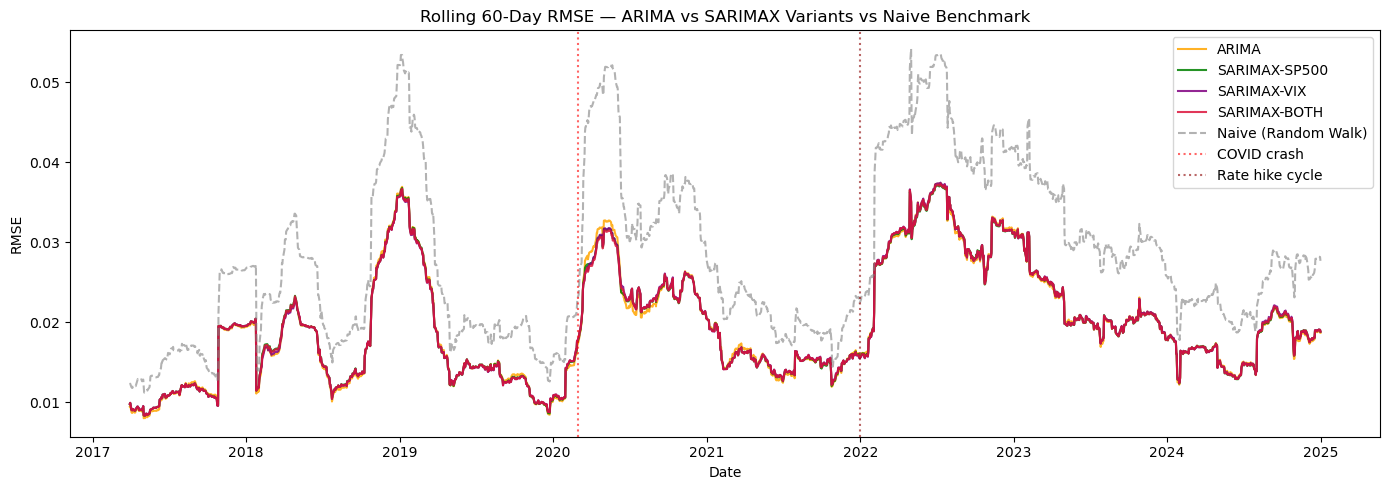

In [34]:
window = 60

rolling_rmse_arima = (
    (y_test_naive - arima_naive) ** 2
).rolling(window).mean().apply(np.sqrt)

rolling_rmse_sarimax_sp = (
    (y_test_naive - sarimax_sp_naive) ** 2
).rolling(window).mean().apply(np.sqrt)

rolling_rmse_sarimax_vix = (
    (y_test_naive - sarimax_vix_naive) ** 2
).rolling(window).mean().apply(np.sqrt)

rolling_rmse_sarimax_both = (
    (y_test_naive - sarimax_both_naive) ** 2
).rolling(window).mean().apply(np.sqrt)

rolling_rmse_naive = (
    (y_test_naive - naive_forecast) ** 2
).rolling(window).mean().apply(np.sqrt)

plt.figure(figsize=(14, 5))

plt.plot(rolling_rmse_arima, label="ARIMA", color="orange", alpha=0.85)
plt.plot(rolling_rmse_sarimax_sp, label="SARIMAX-SP500", color="green", alpha=0.85)
plt.plot(rolling_rmse_sarimax_vix, label="SARIMAX-VIX", color="purple", alpha=0.85)
plt.plot(rolling_rmse_sarimax_both, label="SARIMAX-BOTH", color="crimson", alpha=0.85)
plt.plot(rolling_rmse_naive, label="Naive (Random Walk)", color="gray", alpha=0.6, linestyle="--")

plt.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle=":", alpha=0.6, label="COVID crash")
plt.axvline(pd.Timestamp("2022-01-01"), color="darkred", linestyle=":", alpha=0.6, label="Rate hike cycle")

plt.title(f"Rolling {window}-Day RMSE — ARIMA vs SARIMAX Variants vs Naive Benchmark")
plt.ylabel("RMSE")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation**

- Peaks in rolling RMSE coincide with periods of market stress (notably the COVID shock in 2020 and the 2022 tightening cycle), during which all models experience a deterioration in predictive accuracy.
- ARIMA and the SARIMAX variants display very similar rolling RMSE profiles over time, suggesting that the inclusion of lagged SP500 and VIX information provides only marginal incremental forecasting value.
- All statistical models consistently outperform the naive random-walk benchmark, but their errors rise substantially during extreme market regimes, confirming that next-day return prediction remains challenging in turbulent periods.

## 6. Performance Across Market Regimes

We evaluate ARIMA, SARIMAX, and the naïve benchmark on three distinct sub-periods:

- **Normal period** (2017–2019): relatively calm market, low volatility,
- **COVID crash** (2020): extreme volatility spike and rapid recovery,
- **Rate hike sell-off** (2022–2023): sustained bear market driven by monetary tightening.

In [37]:
regimes = {
    "Normal (2017–2019)": ("2017-01-01", "2019-12-31"),
    "COVID Crash (2020)": ("2020-01-01", "2020-12-31"),
    "Rate Hike Sell-off (2022–2023)": ("2022-01-01", "2023-12-31"),
}

regime_results = []

for regime_name, (start, end) in regimes.items():
    y_sub = y_test.loc[start:end]
    naive_s = y_sub.shift(1).dropna()
    y_sub_n = y_sub.loc[naive_s.index]

    model_specs = [
        ("ARIMA", arima_forecast.loc[y_sub_n.index]),
        ("SARIMAX-SP500", sarimax_sp_forecast.loc[y_sub_n.index]),
        ("SARIMAX-VIX", sarimax_vix_forecast.loc[y_sub_n.index]),
        ("SARIMAX-BOTH", sarimax_both_forecast.loc[y_sub_n.index]),
        ("Naive", naive_s),
    ]

    for model_name, preds in model_specs:
        rmse = np.sqrt(mean_squared_error(y_sub_n, preds))
        da = np.mean(np.sign(y_sub_n) == np.sign(preds)) * 100

        regime_results.append({
            "Regime": regime_name,
            "Model": model_name,
            "RMSE": round(rmse, 6),
            "Directional Acc. (%)": round(da, 2)
        })

regime_df = pd.DataFrame(regime_results).set_index(["Regime", "Model"])
display(regime_df)

RMSE  Directional Acc. (%)
Regime                         Model                                        
Normal (2017–2019)             ARIMA          0.017300                 55.91
                               SARIMAX-SP500  0.017331                 51.13
                               SARIMAX-VIX    0.017268                 49.27
                               SARIMAX-BOTH   0.017303                 49.54
                               Naive          0.024618                 52.86
COVID Crash (2020)             ARIMA          0.024240                 55.16
                               SARIMAX-SP500  0.024065                 51.98
                               SARIMAX-VIX    0.024135                 47.22
                               SARIMAX-BOTH   0.024026                 51.19
                               Naive          0.036639                 50.40
Rate Hike Sell-off (2022–2023) ARIMA          0.026819                 50.20
                               SARIMAX-SP500  0.026817                 51.00
                               SARIMAX-VIX    0.026909                 47.60
                               SARIMAX-BOTH   0.026851                 50.80
                               Naive          0.038166                 50.00

### Interpretation across market regimes

The regime-specific evaluation reveals that model performance is not uniform across market conditions. In the **normal period (2017–2019)**, all statistical models perform similarly in terms of RMSE, with a slight edge for **SARIMAX-VIX**, while **ARIMA** clearly achieves the highest directional accuracy. During the **COVID crash (2020)**, the combined specification **SARIMAX-BOTH** attains the lowest RMSE, suggesting that exogenous market information becomes somewhat more useful during extreme stress episodes, although **ARIMA** still delivers the best directional performance. In the **rate hike sell-off (2022–2023)**, **SARIMAX-SP500** emerges as the strongest model on both RMSE and directional accuracy, indicating that lagged broad-market returns are particularly informative in sustained macro-driven downturns.

Overall, these results suggest that exogenous variables can provide **modest regime-dependent gains**, especially during stressed market environments, but the improvements remain small. **ARIMA** remains the most robust and parsimonious benchmark across sub-periods, while **SP500-based models** appear to add the most value when market-wide forces dominate individual stock dynamics.

## 7. Stress Test : Zoom on Crisis Periods

We zoom in on the two main stress periods to visually inspect how models behave when market conditions are extreme.

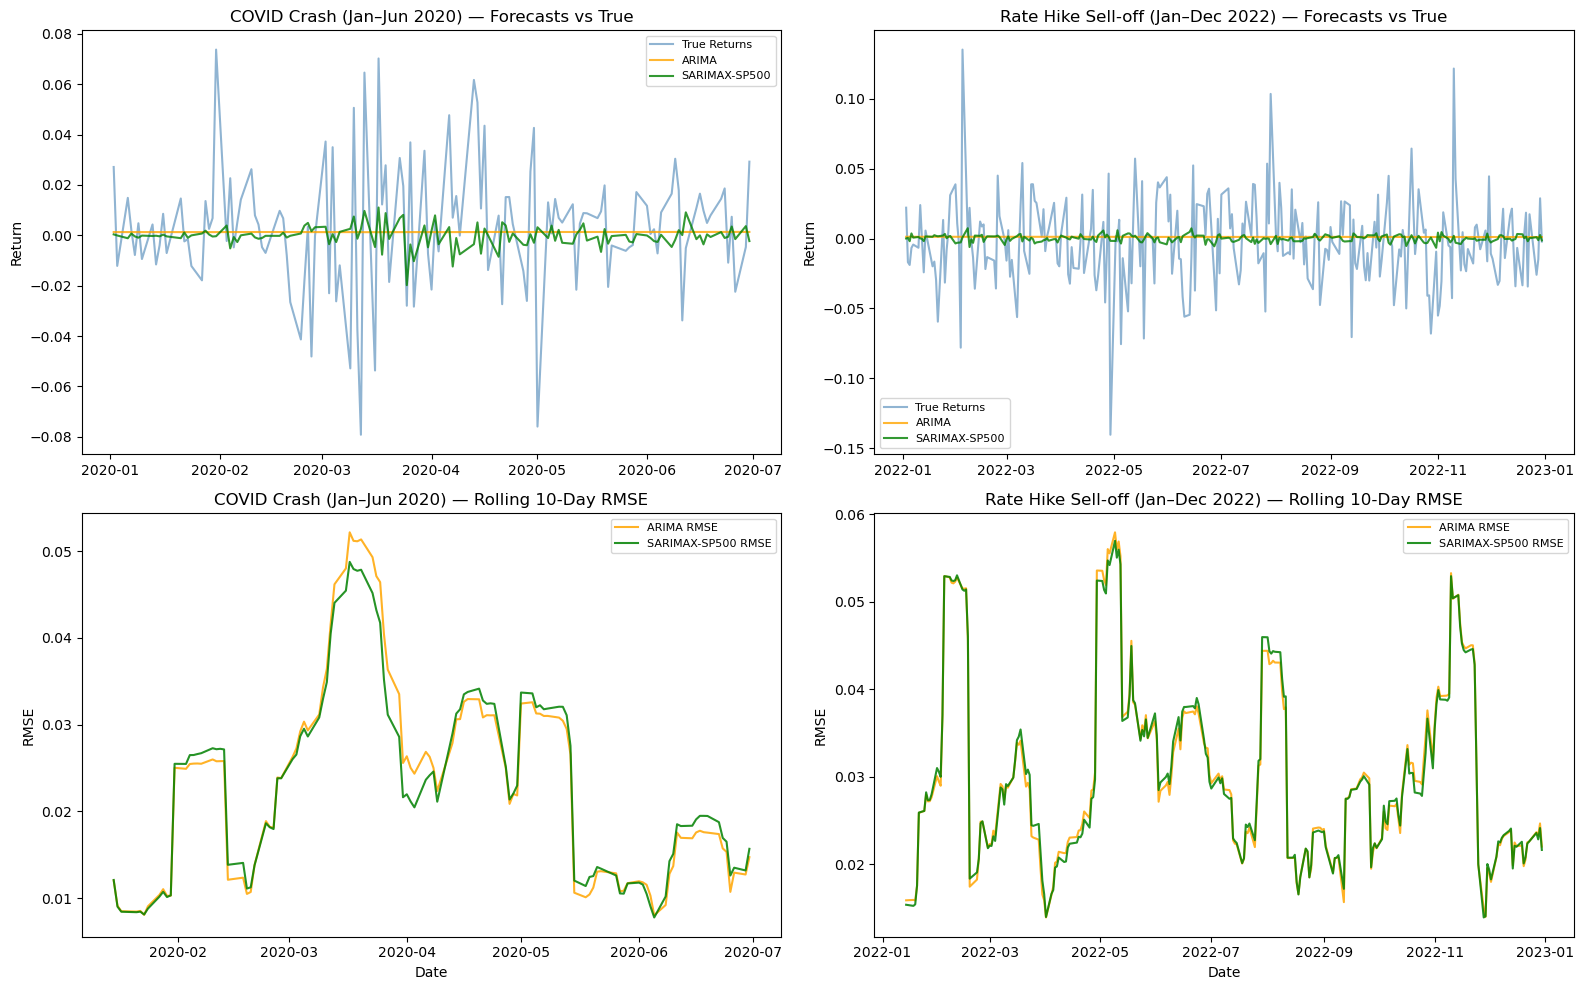

In [40]:
stress_periods = {
    "COVID Crash (Jan–Jun 2020)": ("2020-01-01", "2020-06-30"),
    "Rate Hike Sell-off (Jan–Dec 2022)": ("2022-01-01", "2022-12-31"),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

for col, (period_name, (start, end)) in enumerate(stress_periods.items()):
    y_sub = y_test.loc[start:end]
    a_sub = arima_forecast.loc[start:end]
    s_sub = sarimax_sp_forecast.loc[start:end]   # <- correction ici

    # Forecasts vs true returns
    axes[0, col].plot(y_sub.index, y_sub, label="True Returns", alpha=0.6, color="steelblue")
    axes[0, col].plot(a_sub.index, a_sub, label="ARIMA", alpha=0.8, color="orange")
    axes[0, col].plot(s_sub.index, s_sub, label="SARIMAX-SP500", alpha=0.8, color="green")
    axes[0, col].set_title(f"{period_name} — Forecasts vs True")
    axes[0, col].set_ylabel("Return")
    axes[0, col].legend(fontsize=8)

    # Rolling 10-day RMSE during stress
    rmse_a = ((y_sub - a_sub) ** 2).rolling(10).mean().apply(np.sqrt)
    rmse_s = ((y_sub - s_sub) ** 2).rolling(10).mean().apply(np.sqrt)

    axes[1, col].plot(rmse_a.index, rmse_a, label="ARIMA RMSE", color="orange", alpha=0.85)
    axes[1, col].plot(rmse_s.index, rmse_s, label="SARIMAX-SP500 RMSE", color="green", alpha=0.85)
    axes[1, col].set_title(f"{period_name} — Rolling 10-Day RMSE")
    axes[1, col].set_ylabel("RMSE")
    axes[1, col].set_xlabel("Date")
    axes[1, col].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Stress-period interpretation

The stress-period zoom confirms that both ARIMA and SARIMAX-SP500 struggle to capture the large daily return swings observed during extreme market episodes. In both the COVID crash and the 2022 rate-hike sell-off, forecasts remain centered close to zero relative to the magnitude of realized returns.

The rolling 10-day RMSE nevertheless suggests that SARIMAX-SP500 can occasionally deliver small local improvements over ARIMA during turbulent periods, especially around some COVID-related volatility bursts. However, these gains remain limited, and the two models exhibit broadly similar forecasting behavior overall.

This visual evidence is consistent with the aggregate out-of-sample results: adding lagged market information may provide slight regime-dependent benefits, but it does not fundamentally solve the difficulty of next-day return prediction during crisis periods.

## 8. Prix Prédit à t+1 vs Prix Réel

Plutôt que de reconstruire un prix sur toute la période (qui accumule les erreurs), on calcule pour chaque jour t le **prix prédit pour le lendemain** en utilisant le vrai prix du jour comme point de départ :

$$\hat{P}_{t+1} = P_t \times (1 + \hat{r}_{t+1})$$

C'est la comparaison honnête à horizon 1 jour : on ne cumule jamais les erreurs, chaque prédiction repart du vrai prix observé.

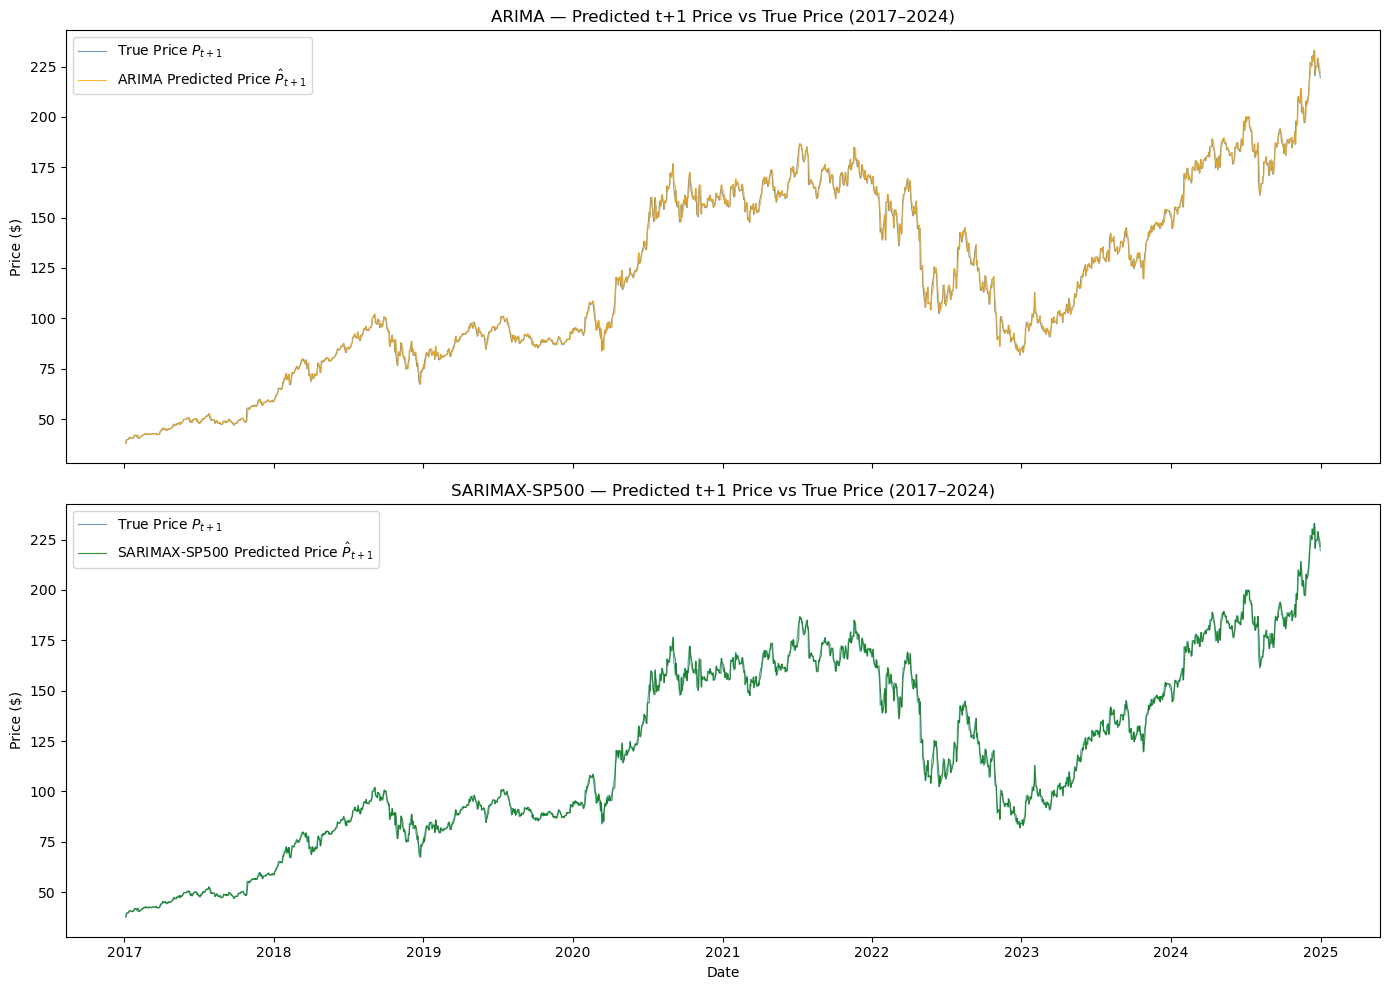

,Price RMSE ($),Price MAE ($)
Model,,
ARIMA,2.61,1.77
SARIMAX-SP500,2.61,1.77


In [48]:
# True price on the test set
price_test = data.loc[data.index >= split_date, "Price"]

# t+1 price prediction: use true P_t as base each day
# P_t is the price at t, r_hat_{t+1} is the forecast made at t for t+1
# We shift price by -1 so price_t aligns with forecast_{t+1}
price_t = price_test.shift(1)   # true P_t (yesterday's true price)

# Align everything
common = (
    price_t.dropna().index
    .intersection(arima_forecast.index)
    .intersection(sarimax_sp_forecast.index)
)

p_true = price_test.loc[common]                       # true P_{t+1}
p_t = price_t.loc[common]                             # true P_t (base)
p_hat_arima = p_t * (1 + arima_forecast.loc[common])  # predicted P_{t+1} with ARIMA
p_hat_sarimax = p_t * (1 + sarimax_sp_forecast.loc[common])  # predicted P_{t+1} with SARIMAX-SP500

# --- Full test period ---
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(p_true.index, p_true, label="True Price $P_{t+1}$", color="steelblue", alpha=0.8, linewidth=0.8)
axes[0].plot(p_hat_arima.index, p_hat_arima, label="ARIMA Predicted Price $\\hat{P}_{t+1}$", color="orange", alpha=0.8, linewidth=0.8)
axes[0].set_title("ARIMA — Predicted t+1 Price vs True Price (2017–2024)")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

axes[1].plot(p_true.index, p_true, label="True Price $P_{t+1}$", color="steelblue", alpha=0.8, linewidth=0.8)
axes[1].plot(p_hat_sarimax.index, p_hat_sarimax, label="SARIMAX-SP500 Predicted Price $\\hat{P}_{t+1}$", color="green", alpha=0.8, linewidth=0.8)
axes[1].set_title("SARIMAX-SP500 — Predicted t+1 Price vs True Price (2017–2024)")
axes[1].set_ylabel("Price ($)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Price prediction metrics ---
rmse_price_arima = np.sqrt(np.mean((p_true - p_hat_arima) ** 2))
rmse_price_sarimax = np.sqrt(np.mean((p_true - p_hat_sarimax) ** 2))

mae_price_arima = np.mean(np.abs(p_true - p_hat_arima))
mae_price_sarimax = np.mean(np.abs(p_true - p_hat_sarimax))

price_metrics = pd.DataFrame([
    {"Model": "ARIMA", "Price RMSE ($)": round(rmse_price_arima, 2), "Price MAE ($)": round(mae_price_arima, 2)},
    {"Model": "SARIMAX-SP500", "Price RMSE ($)": round(rmse_price_sarimax, 2), "Price MAE ($)": round(mae_price_sarimax, 2)},
]).set_index("Model")

display(price_metrics)

### Price forecasting results

To assess the practical implications of return forecasting, we reconstruct one-step-ahead stock prices using the true observed price at time \(t\) and the predicted return for \(t+1\):
$$
\hat{P}_{t+1} = P_t (1 + \hat{r}_{t+1})
$$
Both **ARIMA** and **SARIMAX-SP500** produce almost identical price forecasts over the full test period. Their reconstructed price paths are nearly indistinguishable from the true observed price series, and both models achieve the same evaluation metrics:

- **Price RMSE:** 2.61
- **Price MAE:** 1.77

This indicates that adding lagged S&P 500 information does not materially improve one-step-ahead stock price prediction relative to the simpler ARIMA benchmark. More broadly, the result shows that even when return predictability is weak, one-step-ahead price reconstruction can remain highly accurate because the forecast is anchored on the true observed price at time \(t\).

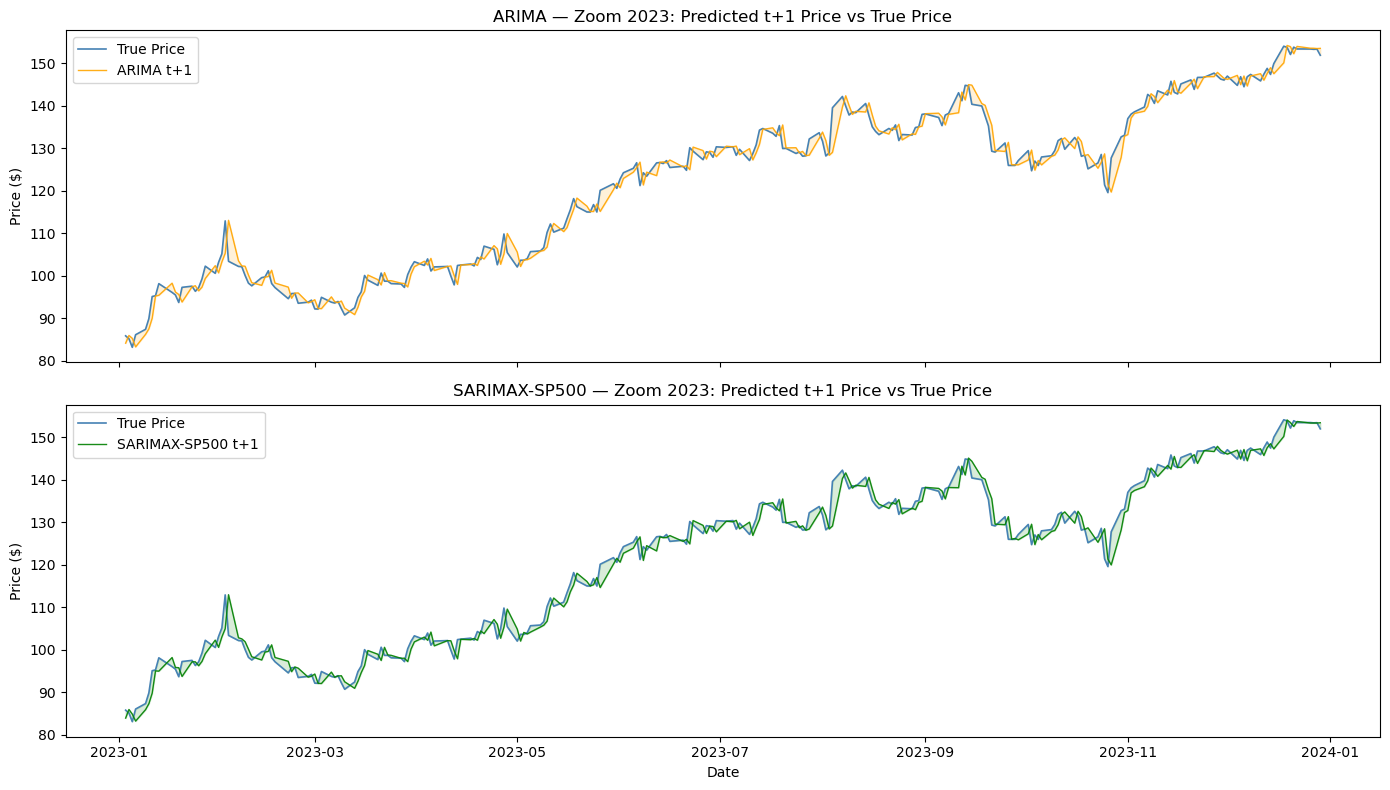

In [47]:
zoom_start, zoom_end = "2023-01-01", "2024-01-01"

p_true_z = p_true.loc[zoom_start:zoom_end]
p_arima_z = p_hat_arima.loc[zoom_start:zoom_end]
p_sarim_z = p_hat_sarimax.loc[zoom_start:zoom_end]   # ici = SARIMAX-SP500

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(p_true_z, label="True Price", color="steelblue", linewidth=1.2)
axes[0].plot(p_arima_z, label="ARIMA t+1", color="orange", linewidth=1.0, alpha=0.9)
axes[0].fill_between(p_true_z.index, p_true_z, p_arima_z, alpha=0.15, color="orange")
axes[0].set_title("ARIMA — Zoom 2023: Predicted t+1 Price vs True Price")
axes[0].set_ylabel("Price ($)")
axes[0].legend()

axes[1].plot(p_true_z, label="True Price", color="steelblue", linewidth=1.2)
axes[1].plot(p_sarim_z, label="SARIMAX-SP500 t+1", color="green", linewidth=1.0, alpha=0.9)
axes[1].fill_between(p_true_z.index, p_true_z, p_sarim_z, alpha=0.15, color="green")
axes[1].set_title("SARIMAX-SP500 — Zoom 2023: Predicted t+1 Price vs True Price")
axes[1].set_ylabel("Price ($)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

### Zoom on one-step-ahead price forecasts

A closer look at the 2023 period confirms that both **ARIMA** and **SARIMAX-SP500** generate one-step-ahead price forecasts that remain extremely close to the true observed price path. The predicted and realized series are nearly indistinguishable throughout the year, with only very small local deviations.

Importantly, the SARIMAX-SP500 specification does not produce any visible improvement over the simpler ARIMA benchmark. This visual result is fully consistent with the price forecasting metrics, which showed identical **RMSE** and **MAE** values for both models.

Overall, the figure shows that one-step-ahead stock price reconstruction is highly accurate for both models, but that adding lagged S&P 500 information does not materially improve short-horizon price prediction in this setting.

## 9. Reconstruction de Prix Cumulée (illustrative)

To visualize forecast quality in price space, we compound the t+1 forecasted returns from the last known training price:

$$P_{t+1} = P_t \times (1 + \hat{r}_{t+1})$$

This is illustrative — it shows how return forecast errors accumulate over time, not a claim that the model predicts long-horizon prices.

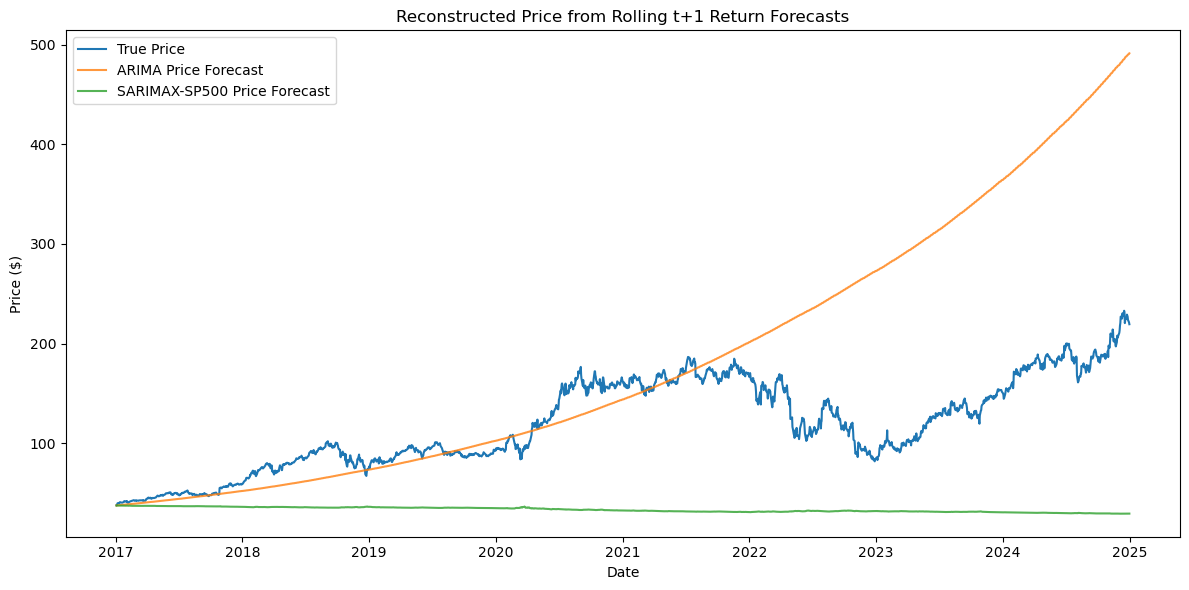

In [50]:
last_train_price = data.loc[data.index < split_date, "Price"].iloc[-1]

price_pred_arima, price_pred_sarimax = [], []
p_arima = p_sarimax = last_train_price

for r_arima, r_sarimax in zip(arima_forecast, sarimax_sp_forecast):
    p_arima = p_arima * (1 + r_arima)
    p_sarimax = p_sarimax * (1 + r_sarimax)
    price_pred_arima.append(p_arima)
    price_pred_sarimax.append(p_sarimax)

price_pred_arima = pd.Series(price_pred_arima, index=arima_forecast.index)
price_pred_sarimax = pd.Series(price_pred_sarimax, index=sarimax_sp_forecast.index)

plt.figure(figsize=(12, 6))
plt.plot(data.loc[data.index >= split_date, "Price"], label="True Price", linewidth=1.5)
plt.plot(price_pred_arima, label="ARIMA Price Forecast", alpha=0.8)
plt.plot(price_pred_sarimax, label="SARIMAX-SP500 Price Forecast", alpha=0.8)

plt.legend()
plt.title("Reconstructed Price from Rolling t+1 Return Forecasts")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

### Illustrative cumulative price reconstruction

Starting from the last observed training price, we recursively compound the one-step-ahead return forecasts over the full test period:
$$
\hat{P}_{t+1} = \hat{P}_t \left(1 + \hat{r}_{t+1}\right)
$$
This exercise is purely illustrative. It shows how even very small forecast biases in daily returns can accumulate over time and produce large divergences in long-horizon reconstructed prices. Therefore, this figure should not be interpreted as a reliable long-term price forecasting result, but rather as evidence of the instability of recursive multi-step price reconstruction when return predictability is weak.

## 10. Consolidated Evaluation Results

We consolidate all evaluation results into a final comparison table.

In [51]:
print("=" * 65)
print("RETURN FORECAST — Full Test Set (2017-2024)")
print("=" * 65)
display(metrics_df)

print("\n" + "=" * 65)
print("VOLATILITY FORECAST — GARCH(1,1)")
print("=" * 65)
display(garch_metrics)

print("\n" + "=" * 65)
print("PERFORMANCE BY MARKET REGIME")
print("=" * 65)
display(regime_df)

RETURN FORECAST — Full Test Set (2017-2024)


,RMSE,MAE,Directional Acc. (%)
Model,,,
ARIMA,0.020811,0.014581,53.51
SARIMAX (SP500),0.020794,0.014627,50.97
SARIMAX (VIX),0.020824,0.014666,48.98
SARIMAX (Both),0.020794,0.014645,50.27
Naive (Random Walk),0.029799,0.020965,51.52



VOLATILITY FORECAST — GARCH(1,1)


,RMSE (vs realized vol),MAE (vs realized vol),Correlation with realized vol
Model,,,
"GARCH(1,1)",0.5977,0.5112,0.8526



PERFORMANCE BY MARKET REGIME


RMSE  Directional Acc. (%)
Regime                         Model                                        
Normal (2017–2019)             ARIMA          0.017300                 55.91
                               SARIMAX-SP500  0.017331                 51.13
                               SARIMAX-VIX    0.017268                 49.27
                               SARIMAX-BOTH   0.017303                 49.54
                               Naive          0.024618                 52.86
COVID Crash (2020)             ARIMA          0.024240                 55.16
                               SARIMAX-SP500  0.024065                 51.98
                               SARIMAX-VIX    0.024135                 47.22
                               SARIMAX-BOTH   0.024026                 51.19
                               Naive          0.036639                 50.40
Rate Hike Sell-off (2022–2023) ARIMA          0.026819                 50.20
                               SARIMAX-SP500  0.026817                 51.00
                               SARIMAX-VIX    0.026909                 47.60
                               SARIMAX-BOTH   0.026851                 50.80
                               Naive          0.038166                 50.00

### Final takeaways

Overall, the results suggest that **ARIMA remains the strongest parsimonious benchmark** for next-day return forecasting, achieving the lowest **MAE** and the highest **directional accuracy** over the full test period. The **SARIMAX-SP500** and **SARIMAX-BOTH** specifications obtain a marginally lower **RMSE**, but the improvement is economically very small. This indicates that adding exogenous market information provides only limited incremental value for short-horizon return prediction.

By contrast, the **GARCH(1,1)** model performs well in forecasting volatility, with a strong correlation with realized volatility (**0.8526**), confirming that **volatility is substantially more predictable than returns**.

## 11. Limitations, Interpretation, and Future Directions

### Why did we model returns instead of raw prices?

We modeled **daily returns** rather than raw stock prices because stock prices are typically **non-stationary**, whereas returns are much closer to being stationary. This matters because ARIMA-type models require a stable mean structure over time.

In other words:

- **Prices** usually contain trends and evolving levels, which violate the stationarity assumptions of linear time-series models.
- **Returns** remove the price level and focus on day-to-day variations, making them more suitable for ARIMA/SARIMAX modeling.

This is also why the differencing order was set to *d = 0* for the return models. Since the return series was already shown to be stationary, no further differencing was required. If we had modeled raw prices directly, a specification with: *d = 1* would likely have been more appropriate.

### Why do the predicted returns look weak, while the predicted prices look very accurate?

At first sight, this may seem contradictory, but the two results are actually fully consistent.

The return models often produce forecasts very close to zero, which reflects a core empirical fact of financial markets: **next-day returns are extremely difficult to predict**. Daily returns are noisy, weakly autocorrelated, and heavily affected by shocks.

However, one-step-ahead price reconstruction is based on the known price at time *t*:

$$\hat{P}_{t+1} = P_t \left(1 + \hat{r}_{t+1}\right)$$

Because the true price *P_t* is already known at forecast time, even a return forecast close to zero can still produce a very accurate one-step-ahead price forecast. Therefore:

- **Return prediction remains weak**
- but **one-step-ahead price prediction can still look visually very good**

This does **not** mean that the models can reliably predict long-horizon price paths on their own. It only means that short-horizon price reconstruction remains accurate when anchored on the true observed price at time *t*.

### Why was ARIMA(0,0,0) selected?

For the univariate benchmark, `auto_arima` selected:

$$\text{ARIMA}(0,0,0)$$

This means that, once the series is expressed in returns, the best univariate specification is simply a constant plus white noise:

$$r_t = \mu + \varepsilon_t$$

This result indicates that past AMZN returns contain **very little linear predictive information** for future AMZN returns. This is consistent with the weak-form view of market efficiency and with the residual diagnostics showing little remaining linear autocorrelation.

So ARIMA(0,0,0) was not chosen arbitrarily: it was selected because the return series behaves like a process with **very weak conditional mean structure**.

### Why was ARIMAX / SARIMAX(2,0,0) selected?

When exogenous regressors were added using `auto_arima(..., X=...)`, all three exogenous specifications selected the same order:

$$(2,0,0)$$

That is:
- **SP500-only**: ARIMAX(2,0,0)
- **VIX-only**: ARIMAX(2,0,0)
- **Both**: ARIMAX(2,0,0)

This means that once market information is included, a parsimonious **AR(2)** structure provides the best in-sample fit according to the information criteria. Importantly, this common selection also allowed a fair comparison across the three exogenous specifications.

Among them:
- **SP500** was the strongest exogenous signal overall
- **VIX** was weaker and often redundant once SP500 was already included
- **BOTH** did not materially improve forecasting performance beyond SP500 alone

Out-of-sample, ARIMA remained the best overall compromise, while the exogenous models provided at most **very small RMSE improvements** in some periods.

### Why did we use GARCH(1,1)?

GARCH addresses a different problem from ARIMA/SARIMAX.

- **ARIMA / ARIMAX / SARIMAX** model the **conditional mean** of returns
- **GARCH** models the **conditional variance** (volatility)

The residual analysis of the return models showed:
- heavy tails
- heteroskedasticity
- volatility clustering

These are exactly the stylized facts that motivate GARCH modeling.

We used: *GARCH(1,1)* because it is the standard benchmark for financial volatility and is often sufficient to capture volatility persistence:
$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

The estimated persistence: *alpha + beta = 0.9111* confirmed strong volatility clustering. Moreover, the model achieved a high correlation with realized volatility: *Corr = 0.8526*

This supports a classic result in empirical finance: **volatility is more predictable than returns.**
So GARCH was useful not for predicting the direction or level of returns, but for capturing **risk dynamics** and stress regimes.

### Main limitations of the current modeling approach

#### 1. Weak predictability of next-day returns
Daily returns contain very little stable signal. Even with exogenous variables, the gain over the ARIMA benchmark remained small.

#### 2. Linear modeling framework
ARIMA-type models assume a linear relationship between past information and future returns. Financial markets are likely driven by more complex, nonlinear, and regime-dependent dynamics.

#### 3. Limited exogenous information
Only a very small external information set was used. In reality, AMZN is also influenced by:
- macro rates
- sector rotation
- earnings announcements
- news sentiment
- options/implied volatility
- market-wide risk appetite
- cross-asset signals

#### 4. Regime instability
The predictive relationships are not constant through time. The model behavior differed across:
- normal periods
- COVID shock
- 2022 tightening regime

This suggests that market structure changes over time.

#### 5. Short-horizon focus
The framework evaluates mainly **one-step-ahead** forecasts. This is useful for statistical testing, but it does not necessarily translate into strong long-horizon price prediction.

### What would improve stock price prediction?

If the objective is to improve **stock price forecasting**, several extensions would be more promising than simply adding one linear exogenous variable.

#### 1. Richer exogenous feature set
Potential additions include:
- VIX level and changes
- Fed Funds rate / bond yields
- Nasdaq / sector ETF returns
- earnings-event dummies
- macro surprise indicators
- sentiment or news scores

#### 2. Regime-switching models
A Markov-switching or threshold framework could explicitly model different regimes:
- calm market
- crisis market
- macro tightening regime

This would be more realistic than assuming one stable relationship over the whole sample.

#### 3. Better volatility integration
Since volatility is predictable, it may be useful to combine mean and variance more explicitly, for example with:
- **GARCH-in-Mean**
- **EGARCH**
- **GJR-GARCH**

These models may better capture asymmetric and regime-sensitive volatility effects.

#### 4. Nonlinear machine learning models
To improve price prediction, one could also test:
- gradient boosting / XGBoost with lagged features
- random forest with careful time-series validation
- LSTM / GRU
- Transformer-based sequence models

These approaches may capture nonlinear temporal relationships that ARIMA cannot.

#### 5. Multi-horizon forecasting design
Instead of only forecasting *t+1*, a dedicated framework for:
- 5-day horizon
- 20-day horizon
- direct price target prediction

could be explored, depending on the final business objective.

## Final conclusion

This project shows that **next-day AMZN returns are very difficult to predict**, even when lagged market information is included. The univariate benchmark selected by `auto_arima`, **ARIMA(0,0,0)**, already captured the fact that the return series contains very little exploitable linear structure.

Adding exogenous variables led to a common **SARIMAX(2,0,0)** specification, but the out-of-sample improvements remained very small. **ARIMA** delivered the best overall compromise, with the lowest **MAE** and the highest **directional accuracy**, while **SARIMAX-SP500** and **SARIMAX-BOTH** achieved only marginal RMSE gains.

At the same time, the project also shows why **price forecasts can look very accurate even when return forecasts are weak**: one-step-ahead price prediction is anchored on the true observed price at time *t*, which strongly stabilizes the forecast.

Finally, **GARCH(1,1)** proved genuinely useful for a different task: modeling **volatility**, not returns. Its strong fit against realized volatility confirms that while the **conditional mean of returns is hard to predict, volatility dynamics are much more structured and forecastable**.

Overall, these models provide a rigorous and interpretable baseline. Their limitations clearly motivate richer exogenous variables, regime-aware models, and nonlinear approaches as the next step toward improving stock price prediction.